In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#new = "report.csv"
#old = "../analysis-grand-challenge/analyses/cms-open-data-ttbar/report.csv"
#new = "report_daskcfrvirtual_local.csv"

#new = "report_virtualarrays.csv"
#old = "../analysis-grand-challenge/analyses/cms-open-data-ttbar/report.csv"

new = "report_virtualarrays_local.csv"
old = "../analysis-grand-challenge/analyses/cms-open-data-ttbar/report_local.csv"

new_df = pd.read_csv(new)
old_df = pd.read_csv(old)

#new_df = new_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].mean()
#old_df = old_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].mean()
new_df = new_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].min()
old_df = old_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].min()

def seconds_to_minutes(seconds):
    return seconds / 60

old_df['execution_time'] = old_df['execution_time'].apply(seconds_to_minutes)
new_df['execution_time'] = new_df['execution_time'].apply(seconds_to_minutes)

In [3]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def abbreviate_number(num):
    """Convert number to human-readable format (e.g., 1.2k, 3.4M)"""
    suffixes = ['', 'k', 'M', 'B', 'T', 'P', 'E']  # can extend as needed
    num_abs = abs(num)
    i = 0
    while num_abs >= 1000 and i < len(suffixes) - 1:
        num /= 1000.0
        num_abs /= 1000.0
        i += 1
    if num % 1 == 0:
        return f"{int(num)}{suffixes[i]}"
    else:
        return f"{num:.1f}{suffixes[i]}"


def plot_execution_time(old_df, new_df, x_var, title, loc='upper left', fontsize=8, mode="old"):
    if mode == "old":
        label_old = "coffea 0.7.*"
        label_new = "coffea 202*"
    else:
        label_old = "dask-awkward"
        label_new = "virtual arrays"
    #plt.figure(figsize=(10, 6))
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Determine the other two variables to differentiate the lines
    vars_to_vary = [col for col in ['n_files', 'n_workers', 'chunksize'] if col != x_var]
    
    # Unique combinations for line differentiation
    combinations = old_df[vars_to_vary].drop_duplicates().reset_index(drop=True)
    n_combinations = len(combinations)

    # Adjust color intensity range to avoid very light shades
    color_range = np.linspace(0.3, 0.9, n_combinations)
    old_cmap = cm.get_cmap('Blues')
    new_cmap = cm.get_cmap('Reds')

    # Plot for OLD data (shades of blue)
    for i, combo in combinations.iterrows():
        condition = (old_df[vars_to_vary[0]] == combo[vars_to_vary[0]]) & \
                    (old_df[vars_to_vary[1]] == combo[vars_to_vary[1]])
        subset = old_df[condition].sort_values(by=x_var)

        ax.plot(subset[x_var], subset['execution_time'],
                 label=f'{label_old} - {vars_to_vary[0]}={abbreviate_number(combo[vars_to_vary[0]])}, {vars_to_vary[1]}={abbreviate_number(combo[vars_to_vary[1]])}',
                 linestyle='-', marker='o', color=old_cmap(color_range[i]))

    # Plot for NEW data (shades of red)
    for i, combo in combinations.iterrows():
        condition = (new_df[vars_to_vary[0]] == combo[vars_to_vary[0]]) & \
                    (new_df[vars_to_vary[1]] == combo[vars_to_vary[1]])
        subset = new_df[condition].sort_values(by=x_var)

        ax.plot(subset[x_var], subset['execution_time'],
                 label=f'{label_new} - {vars_to_vary[0]}={abbreviate_number(combo[vars_to_vary[0]])}, {vars_to_vary[1]}={abbreviate_number(combo[vars_to_vary[1]])}',
                 linestyle='--', marker='s', color=new_cmap(color_range[i]))

    # Formatting
    ax.set_xlabel(x_var)
    ax.set_ylabel('Execution Time (minutes)')
    ax.set_title(title)
    #ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.legend(loc=loc, fontsize=fontsize, ncol=2)
    fig.tight_layout()
    plt.show()
    # save as png
    fig.savefig(f"{title.replace(' ', '_').lower()}_{mode}.png", bbox_inches='tight')
    # save as pdf
    fig.savefig(f"{title.replace(' ', '_').lower()}_{mode}.pdf", bbox_inches='tight')

/tmp/ipykernel_360292/1403000028.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = cm.get_cmap('Blues')
/tmp/ipykernel_360292/1403000028.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  new_cmap = cm.get_cmap('Reds')


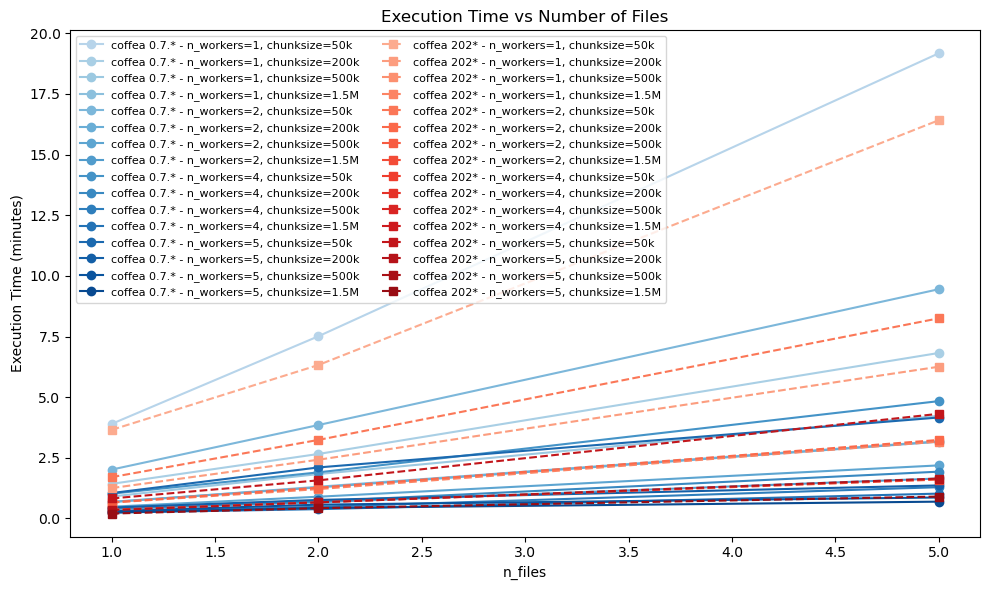

/tmp/ipykernel_360292/1403000028.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = cm.get_cmap('Blues')
/tmp/ipykernel_360292/1403000028.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  new_cmap = cm.get_cmap('Reds')


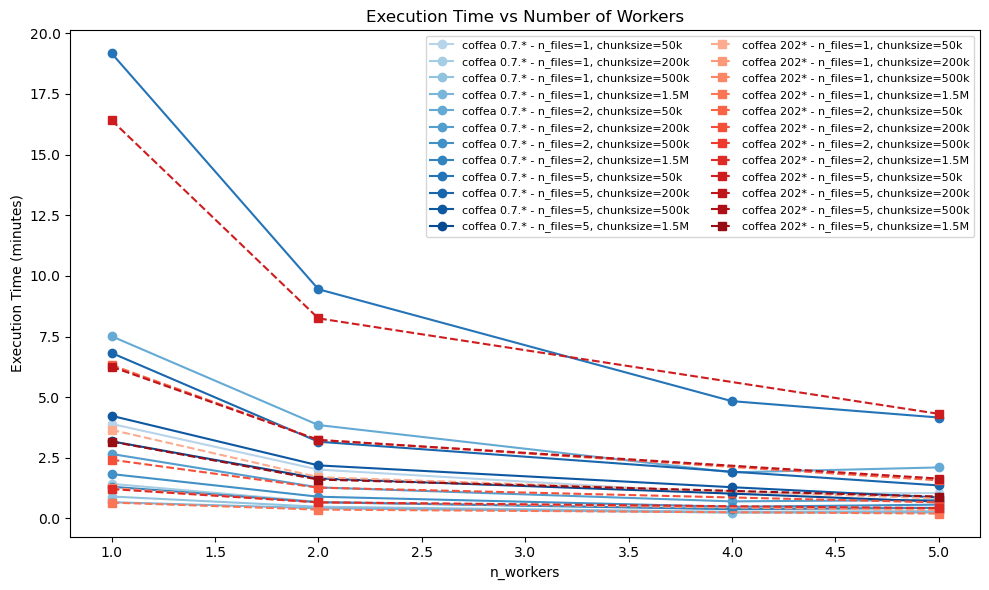

/tmp/ipykernel_360292/1403000028.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = cm.get_cmap('Blues')
/tmp/ipykernel_360292/1403000028.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  new_cmap = cm.get_cmap('Reds')


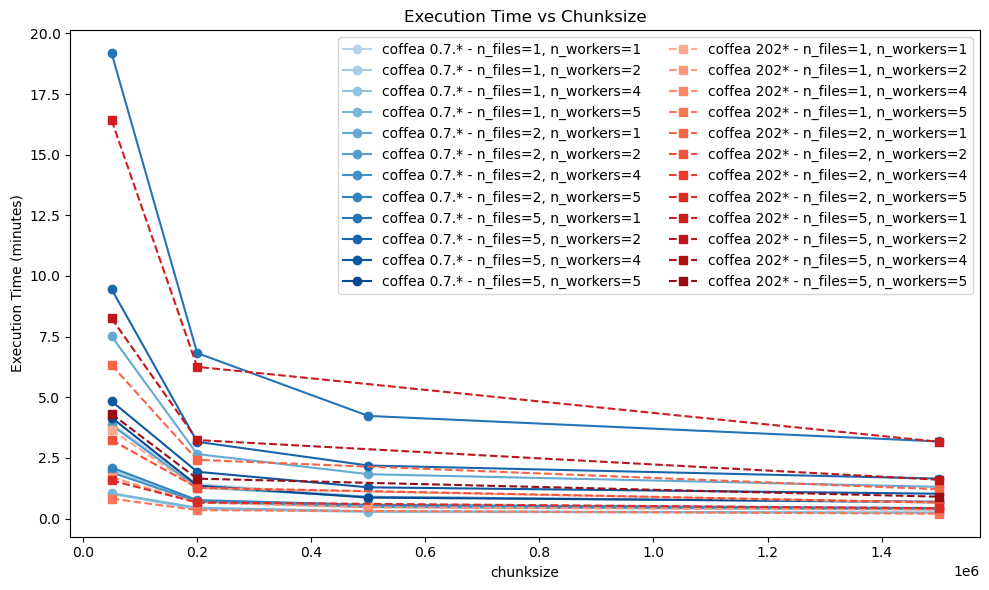

In [55]:
#old_df = old_df[(old_df["n_workers"].isin([1, 2, 5])) & (old_df["n_files"].isin([1, 2, 5, 8])) & (old_df["chunksize"] == 200000)]
#new_df = new_df[(new_df["n_workers"].isin([1, 2, 5])) & (new_df["n_files"].isin([1, 2, 5, 8])) & (new_df["chunksize"] == 200000)]
#old_df = old_df[(old_df["chunksize"].isin([50000, 200000, 1500000])) & (old_df["n_files"].isin([1, 2, 5])) & (old_df["chunksize"] == 200000)]
#new_df = new_df[(new_df["chunksize"].isin([50000, 200000, 1500000])) & (new_df["n_files"].isin([1, 2, 5])) & (new_df["chunksize"] == 200000)]

plot_execution_time(old_df, new_df, 'n_files', 'Execution Time vs Number of Files', fontsize=8)
plot_execution_time(old_df, new_df, 'n_workers', 'Execution Time vs Number of Workers', loc='upper right', fontsize=8)
plot_execution_time(old_df, new_df, 'chunksize', 'Execution Time vs Chunksize', loc='upper right', fontsize=10)

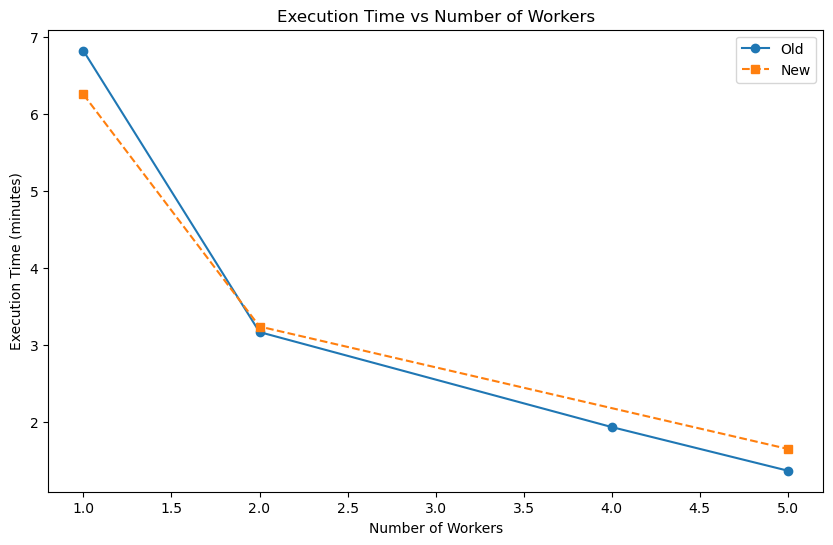

In [56]:
new_df = pd.read_csv(new)
old_df = pd.read_csv(old)

new_df = new_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].min()
old_df = old_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].min()

def seconds_to_minutes(seconds):
    return seconds / 60

old_df['execution_time'] = old_df['execution_time'].apply(seconds_to_minutes)
new_df['execution_time'] = new_df['execution_time'].apply(seconds_to_minutes)

# in both cases, keep only the configurations with 5 files and chunksize 500000
old_df_l = old_df[(old_df['n_files'] == 5) & (old_df['chunksize'] == 200000)]
new_df_l = new_df[(new_df['n_files'] == 5) & (new_df['chunksize'] == 200000)]

# plot the execution time vs number of workers
plt.figure(figsize=(10, 6))
plt.plot(old_df_l['n_workers'], old_df_l['execution_time'], label='Old', linestyle='-', marker='o')
plt.plot(new_df_l['n_workers'], new_df_l['execution_time'], label='New', linestyle='--', marker='s')
plt.xlabel('Number of Workers')
plt.ylabel('Execution Time (minutes)')
plt.title('Execution Time vs Number of Workers')
plt.legend()
plt.show()

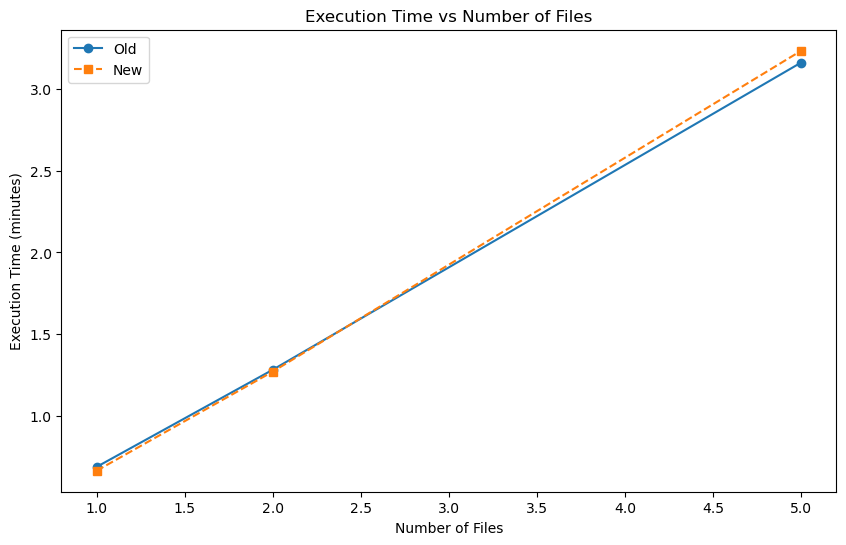

In [6]:
old_df_l = old_df[(old_df['chunksize'] == 200000) & (old_df['n_workers'] == 2)]
new_df_l = new_df[(new_df['chunksize'] == 200000) & (new_df['n_workers'] == 2)]

# plot the execution time vs number of workers
plt.figure(figsize=(10, 6))
plt.plot(old_df_l['n_files'], old_df_l['execution_time'], label='Old', linestyle='-', marker='o')
plt.plot(new_df_l['n_files'], new_df_l['execution_time'], label='New', linestyle='--', marker='s')
plt.xlabel('Number of Files')
plt.ylabel('Execution Time (minutes)')
plt.title('Execution Time vs Number of Files')
plt.legend()
plt.show()

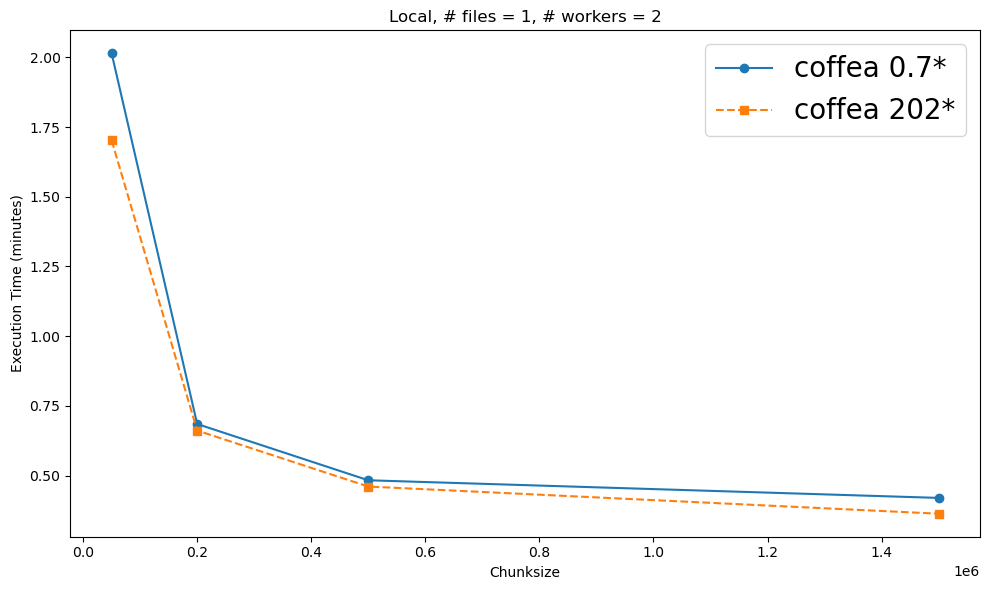

In [12]:
old_df_l = old_df[(old_df['n_files'] == 1) & (old_df['n_workers'] == 2)]
new_df_l = new_df[(new_df['n_files'] == 1) & (new_df['n_workers'] == 2)]

# plot the execution time vs number of workers
#plt.figure(figsize=(10, 6))
#plt.plot(old_df_l['chunksize'], old_df_l['execution_time'], label='Old', linestyle='-', marker='o')
#plt.plot(new_df_l['chunksize'], new_df_l['execution_time'], label='New', linestyle='--', marker='s')
#plt.xlabel('Chunksize')
#plt.ylabel('Execution Time (minutes)')
#plt.title('Execution Time vs Chunksize')
#plt.legend()
#plt.show()
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(old_df_l['chunksize'], old_df_l['execution_time'], label='coffea 0.7*', linestyle='-', marker='o')
ax.plot(new_df_l['chunksize'], new_df_l['execution_time'], label='coffea 202*', linestyle='--', marker='s')
ax.set_xlabel('Chunksize')
ax.set_ylabel('Execution Time (minutes)')
ax.set_title('Local, # files = 1, # workers = 2')
ax.legend(fontsize=20)
fig.tight_layout()
fig.savefig('execution_time_vs_chunksize_reduced.pdf', bbox_inches='tight')
fig.savefig('execution_time_vs_chunksize_reduced.png', bbox_inches='tight')
plt.show()

## virtual vs dask

In [19]:
dsk = "report_daskcfrvirtual.csv"
virtual = "report_virtualarrays.csv"

dsk_df = pd.read_csv(dsk)
virtual_df = pd.read_csv(virtual)

dsk_df = dsk_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].min()
virtual_df = virtual_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].min()

def seconds_to_minutes(seconds):
    return seconds / 60

dsk_df['execution_time'] = dsk_df['execution_time'].apply(seconds_to_minutes)
virtual_df['execution_time'] = virtual_df['execution_time'].apply(seconds_to_minutes)

/tmp/ipykernel_360292/1403000028.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = cm.get_cmap('Blues')
/tmp/ipykernel_360292/1403000028.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  new_cmap = cm.get_cmap('Reds')


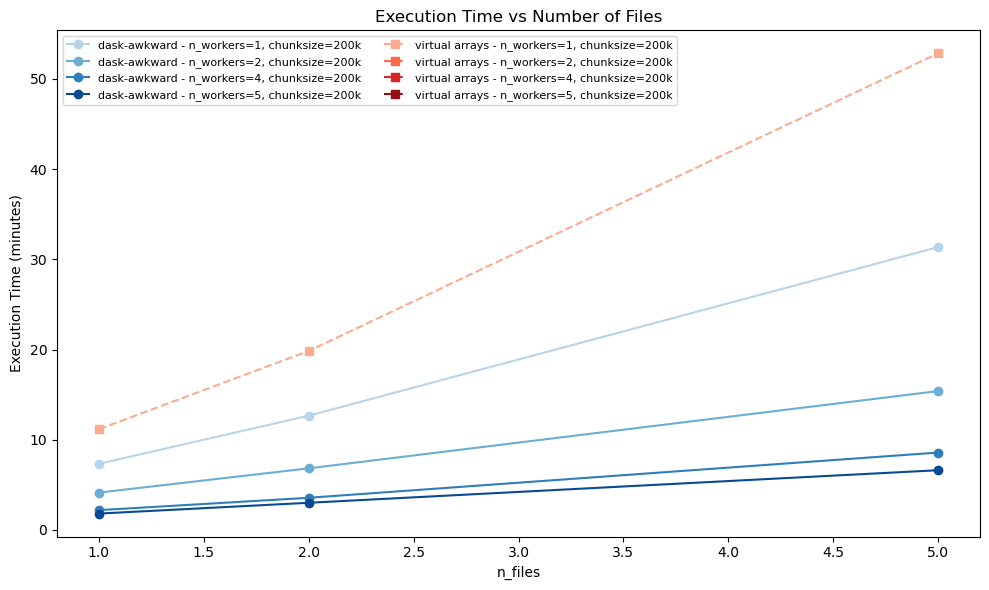

/tmp/ipykernel_360292/1403000028.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = cm.get_cmap('Blues')
/tmp/ipykernel_360292/1403000028.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  new_cmap = cm.get_cmap('Reds')


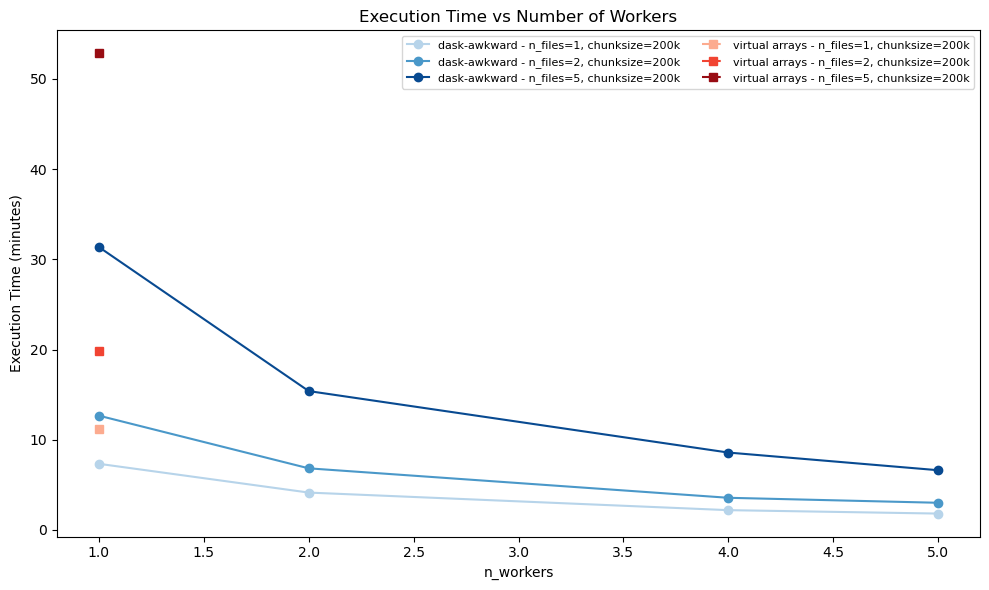

In [20]:
plot_execution_time(dsk_df, virtual_df, 'n_files', 'Execution Time vs Number of Files', fontsize=8, mode="lazy")
plot_execution_time(dsk_df, virtual_df, 'n_workers', 'Execution Time vs Number of Workers', loc='upper right', fontsize=8, mode="lazy")

In [11]:
dsk = "report_daskcfrvirtual_local.csv"
virtual = "report_virtualarrays_local.csv"

dsk_df = pd.read_csv(dsk)
virtual_df = pd.read_csv(virtual)

dsk_df = dsk_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].mean()
virtual_df = virtual_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].mean()

def seconds_to_minutes(seconds):
    return seconds / 60

dsk_df['execution_time'] = dsk_df['execution_time'].apply(seconds_to_minutes)
virtual_df['execution_time'] = virtual_df['execution_time'].apply(seconds_to_minutes)

/tmp/ipykernel_3540610/1403000028.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = cm.get_cmap('Blues')
/tmp/ipykernel_3540610/1403000028.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  new_cmap = cm.get_cmap('Reds')


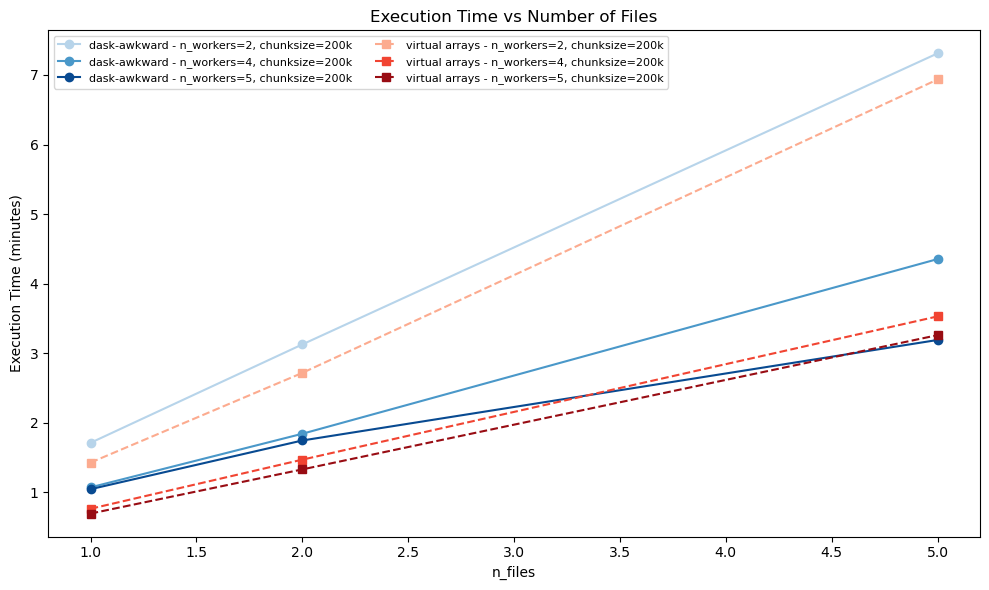

/tmp/ipykernel_3540610/1403000028.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = cm.get_cmap('Blues')
/tmp/ipykernel_3540610/1403000028.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  new_cmap = cm.get_cmap('Reds')


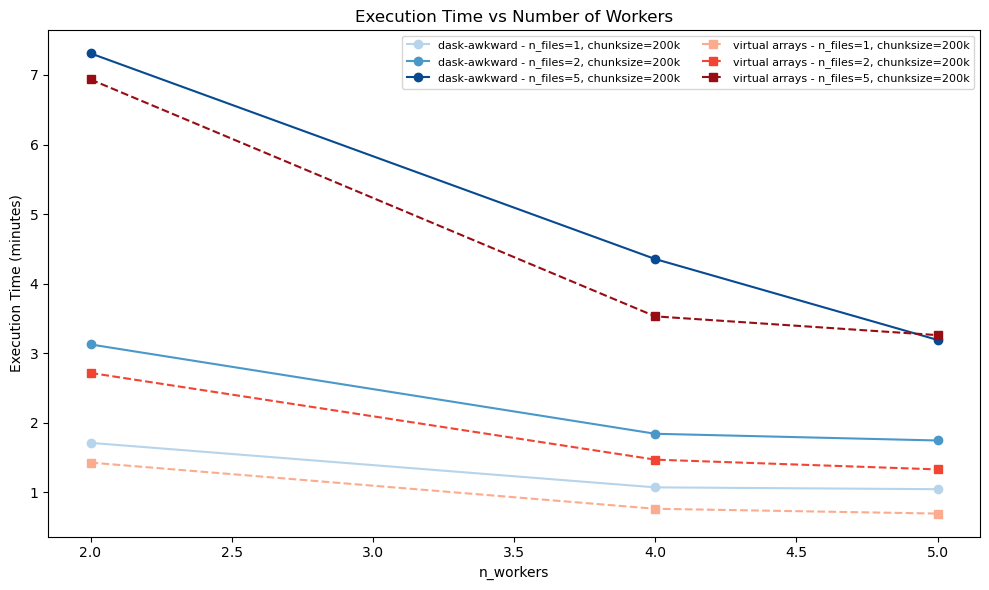

In [12]:
plot_execution_time(dsk_df, virtual_df, 'n_files', 'Execution Time vs Number of Files', fontsize=8, mode="lazy_local")
plot_execution_time(dsk_df, virtual_df, 'n_workers', 'Execution Time vs Number of Workers', loc='upper right', fontsize=8, mode="lazy_local")

## Ultimate comparison

    n_files  n_workers  chunksize  execution_time
0         1          1      50000      296.558191
1         1          1     200000      183.877721
2         1          1    1500000      161.373665
3         1          2      50000      166.892727
4         1          2     200000      106.628704
5         1          2    1500000       94.662779
6         1          4     200000       64.323549
7         1          5      50000       83.438517
8         1          5     200000       59.176917
9         1          5    1500000       60.302308
10        2          1      50000      562.825417
11        2          1     200000      343.707885
12        2          1    1500000      306.461955
13        2          2      50000      317.990191
14        2          2     200000      193.226854
15        2          2    1500000      163.591357
16        2          4     200000      110.548642
17        2          5      50000      138.900568
18        2          5     200000       99.652722


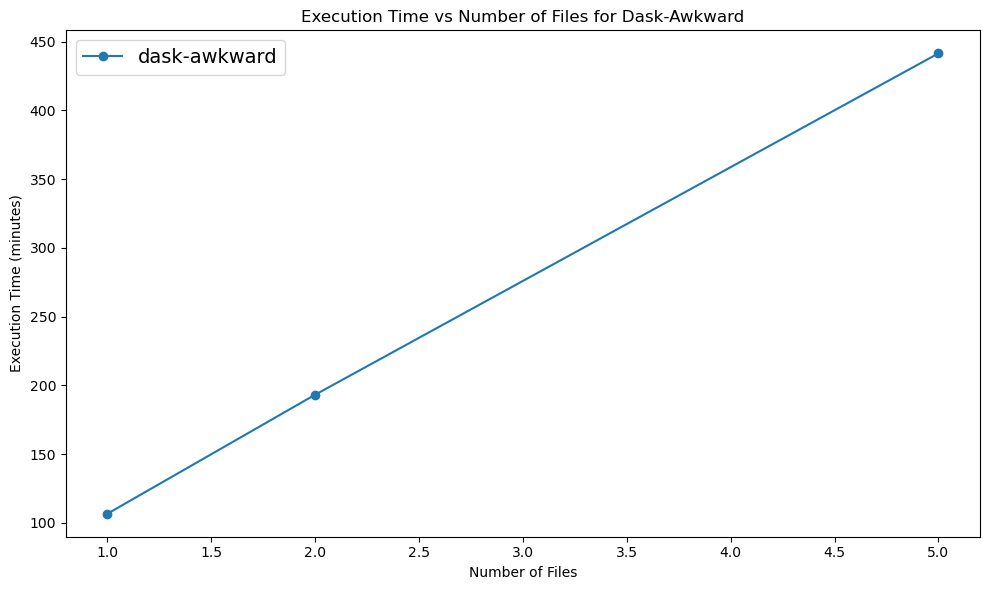

In [8]:
# for one
dsk = "report_daskcfrvirtual_local.csv"
dsk_df = pd.read_csv(dsk)
dsk_df = dsk_df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].mean()
print(dsk_df)
dsk_df = dsk_df[(dsk_df["n_workers"] == 2) & (dsk_df["chunksize"] == 200000)]
print(dsk_df)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dsk_df['n_files'], dsk_df['execution_time'], label='dask-awkward', linestyle='-', marker='o')
ax.set_xlabel('Number of Files')
ax.set_ylabel('Execution Time (minutes)')
ax.set_title('Execution Time vs Number of Files for Dask-Awkward')
ax.legend(fontsize=14)
fig.tight_layout()

/tmp/ipykernel_1207576/4184098447.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "old": cm.get_cmap('Blues'),
/tmp/ipykernel_1207576/4184098447.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "dask": cm.get_cmap('Reds'),
/tmp/ipykernel_1207576/4184098447.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "virtual": cm.get_cmap('Greens'),


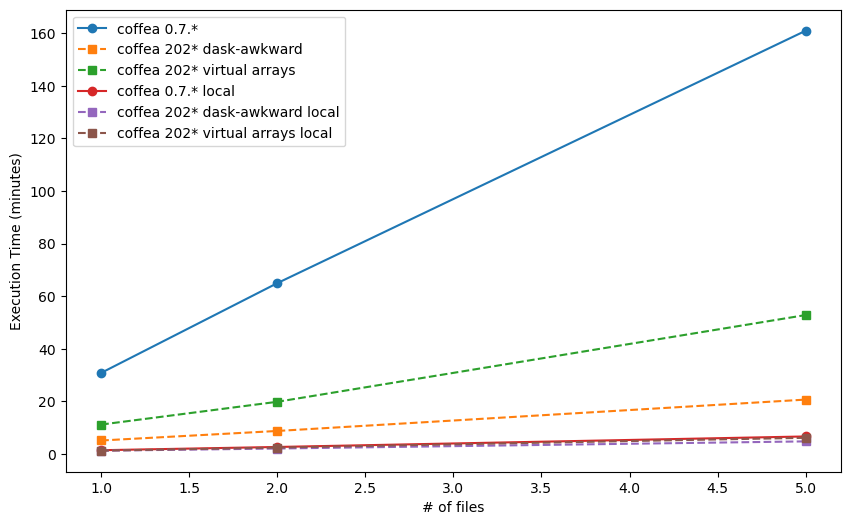

In [6]:
keys = [
    "old", 
    "dask", 
    "virtual", 
    "old_local", 
    "dask_local", 
    "virtual_local"
]
labels = [
    "coffea 0.7.*",
    "coffea 202* dask-awkward", 
    "coffea 202* virtual arrays", 
    "coffea 0.7.* local", 
    "coffea 202* dask-awkward local", 
    "coffea 202* virtual arrays local"
]
dfs_paths = [
    "../analysis-grand-challenge/analyses/cms-open-data-ttbar/report_newpsi.csv",
    "report_daskcfrvirtual.csv",
    "report_virtualarrays.csv",
    "../analysis-grand-challenge/analyses/cms-open-data-ttbar/report_local.csv", 
    "report_daskcfrvirtual_local.csv",
    "report_virtualarrays_local.csv"
]

cmaps = {
    "old": cm.get_cmap('Blues'),
    "dask": cm.get_cmap('Reds'),
    "virtual": cm.get_cmap('Greens'),
}

fig, ax = plt.subplots(figsize=(10, 6))
for key, path in zip(keys, dfs_paths):
    df = pd.read_csv(path)
    df = df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].mean()
    df['execution_time'] = df['execution_time'].apply(seconds_to_minutes)
    df = df[(df["n_workers"] == 1) & (df["chunksize"] == 200000)]
    
    if key.startswith("old"):
        
        linestyle = '-'
        marker = 'o'
    else:
        linestyle = '--'
        marker = 's'
    
    ax.plot(df['n_files'], df['execution_time'], label=labels[keys.index(key)], linestyle=linestyle, marker=marker)
    ax.legend(fontsize=10, loc='upper left')
    ax.set_xlabel('# of files')
    ax.set_ylabel('Execution Time (minutes)')

/tmp/ipykernel_1412831/160851046.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "old": cm.get_cmap('Blues'),
/tmp/ipykernel_1412831/160851046.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "dask": cm.get_cmap('Reds'),
/tmp/ipykernel_1412831/160851046.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "virtual": cm.get_cmap('Greens'),


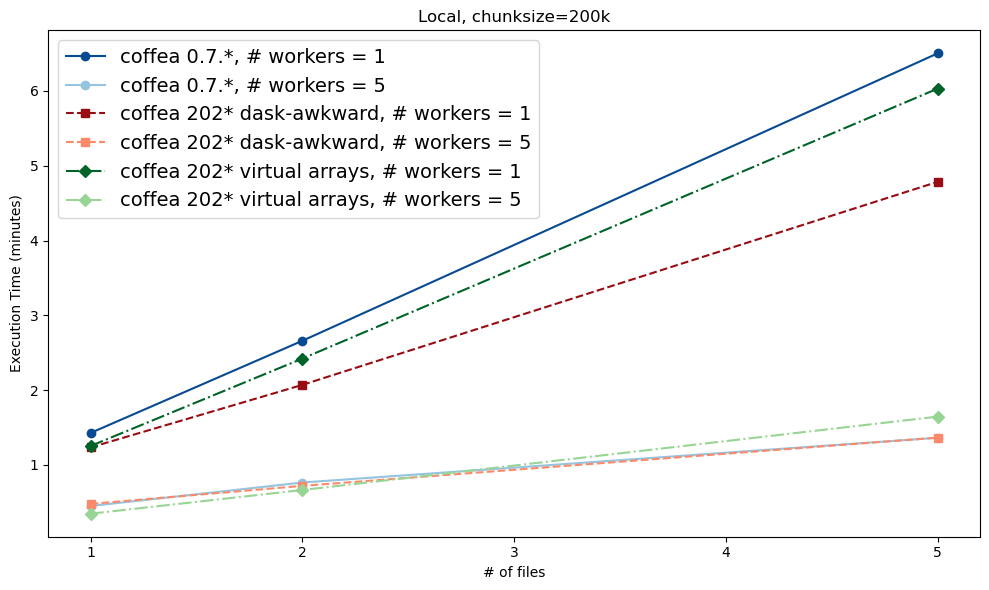

In [13]:
keys = [
    #"old", 
    #"dask", 
    #"virtual", 
    "old_local", 
    "dask_local", 
    "virtual_local"
]
labels = [
    #"coffea 0.7.*",
    #"coffea 202* dask-awkward", 
    #"coffea 202* virtual arrays", 
    "coffea 0.7.*", 
    "coffea 202* dask-awkward", 
    "coffea 202* virtual arrays"
]
dfs_paths = [
    #"../analysis-grand-challenge/analyses/cms-open-data-ttbar/report_newpsi.csv",
    #"report_daskcfrvirtual.csv",
    #"report_virtualarrays.csv",
    "../analysis-grand-challenge/analyses/cms-open-data-ttbar/report_local.csv", 
    "report_daskcfrvirtual_local.csv",
    "report_virtualarrays_local.csv"
]

cmaps = {
    "old": cm.get_cmap('Blues'),
    "dask": cm.get_cmap('Reds'),
    "virtual": cm.get_cmap('Greens'),
}

styles = {
    "old": {'linestyle': '-', 'marker': 'o'},
    "dask": {'linestyle': '--', 'marker': 's'},
    "virtual": {'linestyle': '-.', 'marker': 'D'}
}

fig, ax = plt.subplots(figsize=(10, 6))
for key, path in zip(keys, dfs_paths):
    first_key = key.split('_')[0]  # Get the first part of the key to determine style
    df = pd.read_csv(path)
    df = df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].min()
    df['execution_time'] = df['execution_time'].apply(seconds_to_minutes)
    df = df[(df["chunksize"] == 200000)]
    for i, n_workers in enumerate([1, 5]):
        df_loc = df[df['n_workers'] == n_workers]

        style = styles[first_key]
        linestyle = style['linestyle']
        marker = style['marker']
        color_range = np.linspace(0.4, 0.9, 2)
        color = cmaps[first_key](color_range[2 - 1 - i])

        ax.plot(df_loc['n_files'], df_loc['execution_time'], label=labels[keys.index(key)] + f", # workers = {n_workers}", linestyle=linestyle, marker=marker, color=color)
        ax.legend(fontsize=14, loc='upper left')
        ax.set_xlabel('# of files')
        ax.set_ylabel('Execution Time (minutes)')
        ax.set_title("Local, chunksize=200k")
        # only integers in the axis
        ax.set_xticks(np.arange(df_loc['n_files'].min(), df_loc['n_files'].max() + 1, 1))

fig.tight_layout()
fig.savefig('execution_time_vs_n_files_local.pdf', bbox_inches='tight')
fig.savefig('execution_time_vs_n_files_local.png', bbox_inches='tight')

/tmp/ipykernel_1412831/1797862197.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "old": cm.get_cmap('Blues'),
/tmp/ipykernel_1412831/1797862197.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "dask": cm.get_cmap('Reds'),
/tmp/ipykernel_1412831/1797862197.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "virtual": cm.get_cmap('Greens'),


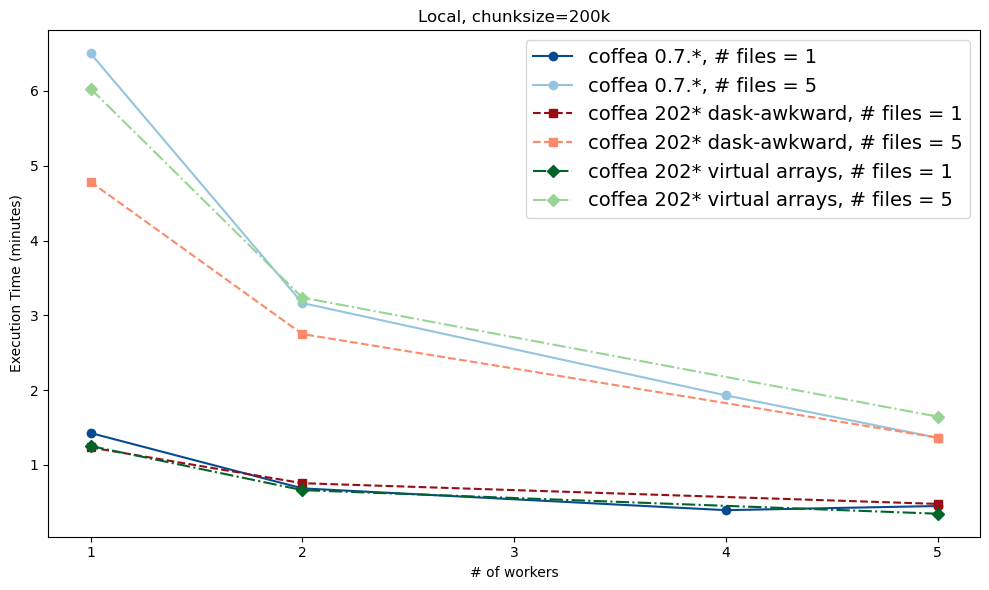

In [14]:
keys = [
    #"old", 
    #"dask", 
    #"virtual", 
    "old_local", 
    "dask_local", 
    "virtual_local"
]
labels = [
    "coffea 0.7.*",
    "coffea 202* dask-awkward", 
    "coffea 202* virtual arrays", 
    #"coffea 0.7.*", 
    #"coffea 202* dask-awkward", 
    #"coffea 202* virtual arrays"
]
dfs_paths = [
    #"../analysis-grand-challenge/analyses/cms-open-data-ttbar/report.csv",
    #"report_daskcfrvirtual.csv",
    #"report_virtualarrays.csv",
    "../analysis-grand-challenge/analyses/cms-open-data-ttbar/report_local.csv", 
    "report_daskcfrvirtual_local.csv",
    "report_virtualarrays_local.csv"
]

cmaps = {
    "old": cm.get_cmap('Blues'),
    "dask": cm.get_cmap('Reds'),
    "virtual": cm.get_cmap('Greens'),
}

styles = {
    "old": {'linestyle': '-', 'marker': 'o'},
    "dask": {'linestyle': '--', 'marker': 's'},
    "virtual": {'linestyle': '-.', 'marker': 'D'}
}

fig, ax = plt.subplots(figsize=(10, 6))
for key, path in zip(keys, dfs_paths):
    first_key = key.split('_')[0]  # Get the first part of the key to determine style
    df = pd.read_csv(path)
    df = df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].min()
    df['execution_time'] = df['execution_time'].apply(seconds_to_minutes)
    df = df[(df["chunksize"] == 200000)]
    for i, n_files in enumerate([1, 5]):
        df_loc = df[df['n_files'] == n_files]

        style = styles[first_key]
        linestyle = style['linestyle']
        marker = style['marker']
        color_range = np.linspace(0.4, 0.9, 2)
        color = cmaps[first_key](color_range[2 - 1 - i])

        ax.plot(df_loc['n_workers'], df_loc['execution_time'], label=labels[keys.index(key)] + f", # files = {n_files}", linestyle=linestyle, marker=marker, color=color)
        ax.legend(fontsize=14, loc='upper right')
        ax.set_xlabel('# of workers')
        ax.set_ylabel('Execution Time (minutes)')
        ax.set_title("Local, chunksize=200k")
        # only integers in the axis
        ax.set_xticks(np.arange(df_loc['n_workers'].min(), df_loc['n_workers'].max() + 1, 1))

fig.tight_layout()
fig.savefig('execution_time_vs_n_workers_local.pdf', bbox_inches='tight')
fig.savefig('execution_time_vs_n_workers_local.png', bbox_inches='tight')

/tmp/ipykernel_1412831/4256290188.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "old": cm.get_cmap('Blues'),
/tmp/ipykernel_1412831/4256290188.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "dask": cm.get_cmap('Reds'),
/tmp/ipykernel_1412831/4256290188.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "virtual": cm.get_cmap('Greens'),


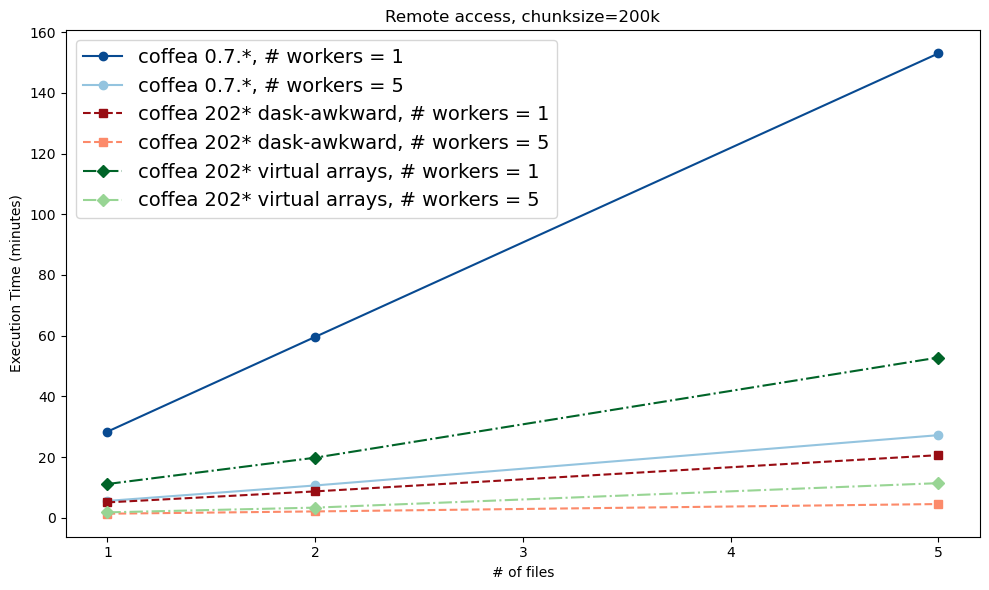

In [17]:
keys = [
    "old", 
    "dask", 
    "virtual", 
    #"old_local", 
    #"dask_local", 
    #"virtual_local"
]
labels = [
    #"coffea 0.7.*",
    #"coffea 202* dask-awkward", 
    #"coffea 202* virtual arrays", 
    "coffea 0.7.*", 
    "coffea 202* dask-awkward", 
    "coffea 202* virtual arrays"
]
dfs_paths = [
    "../analysis-grand-challenge/analyses/cms-open-data-ttbar/report_newpsi.csv",
    "report_daskcfrvirtual.csv",
    "report_virtualarrays.csv",
    #"../analysis-grand-challenge/analyses/cms-open-data-ttbar/report_local.csv", 
    #"report_daskcfrvirtual_local.csv",
    #"report_virtualarrays_local.csv"
]

cmaps = {
    "old": cm.get_cmap('Blues'),
    "dask": cm.get_cmap('Reds'),
    "virtual": cm.get_cmap('Greens'),
}

styles = {
    "old": {'linestyle': '-', 'marker': 'o'},
    "dask": {'linestyle': '--', 'marker': 's'},
    "virtual": {'linestyle': '-.', 'marker': 'D'}
}

fig, ax = plt.subplots(figsize=(10, 6))
for key, path in zip(keys, dfs_paths):
    first_key = key.split('_')[0]  # Get the first part of the key to determine style
    df = pd.read_csv(path)
    df = df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].min()
    df['execution_time'] = df['execution_time'].apply(seconds_to_minutes)
    df = df[(df["chunksize"] == 200000)]
    for i, n_workers in enumerate([1, 5]):
        df_loc = df[df['n_workers'] == n_workers]

        style = styles[first_key]
        linestyle = style['linestyle']
        marker = style['marker']
        color_range = np.linspace(0.4, 0.9, 2)
        color = cmaps[first_key](color_range[2 - 1 - i])

        ax.plot(df_loc['n_files'], df_loc['execution_time'], label=labels[keys.index(key)] + f", # workers = {n_workers}", linestyle=linestyle, marker=marker, color=color)
        ax.legend(fontsize=14, loc='upper left')
        ax.set_xlabel('# of files')
        ax.set_ylabel('Execution Time (minutes)')
        ax.set_title("Remote access, chunksize=200k")
        # only integers in the axis
        ax.set_xticks(np.arange(df_loc['n_files'].min(), df_loc['n_files'].max() + 1, 1))

fig.tight_layout()
fig.savefig('execution_time_vs_n_files_remote.pdf', bbox_inches='tight')
fig.savefig('execution_time_vs_n_files_remote.png', bbox_inches='tight')

/tmp/ipykernel_1412831/2659307472.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "old": cm.get_cmap('Blues'),
/tmp/ipykernel_1412831/2659307472.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "dask": cm.get_cmap('Reds'),
/tmp/ipykernel_1412831/2659307472.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "virtual": cm.get_cmap('Greens'),


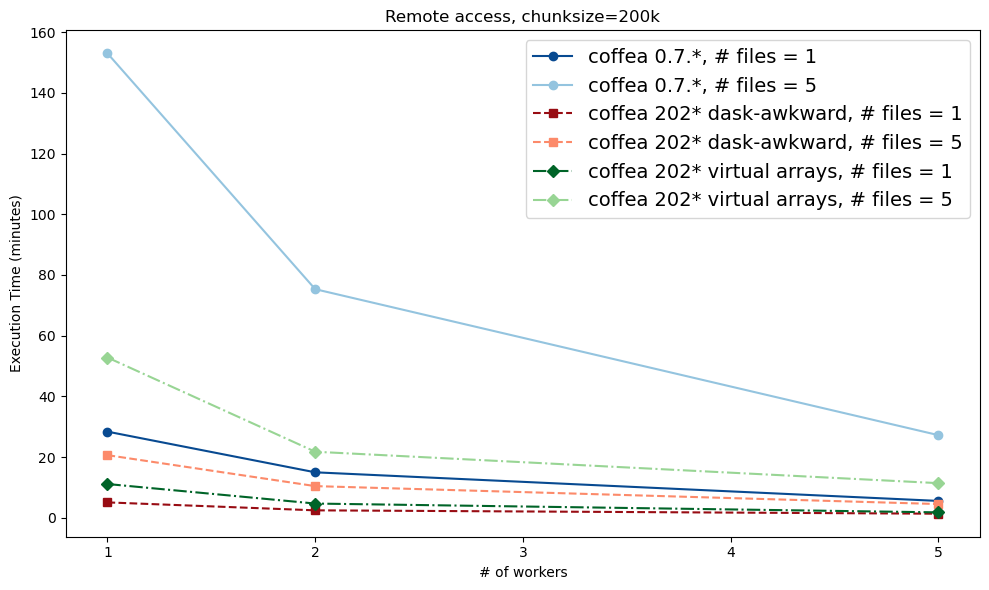

In [16]:
keys = [
    "old", 
    "dask", 
    "virtual", 
    #"old_local", 
    #"dask_local", 
    #"virtual_local"
]
labels = [
    "coffea 0.7.*",
    "coffea 202* dask-awkward", 
    "coffea 202* virtual arrays", 
    #"coffea 0.7.*", 
    #"coffea 202* dask-awkward", 
    #"coffea 202* virtual arrays"
]
dfs_paths = [
    #"../analysis-grand-challenge/analyses/cms-open-data-ttbar/report.csv",
    "../analysis-grand-challenge/analyses/cms-open-data-ttbar/report_newpsi.csv",
    "report_daskcfrvirtual.csv",
    "report_virtualarrays.csv",
    #"../analysis-grand-challenge/analyses/cms-open-data-ttbar/report_local.csv", 
    #"report_daskcfrvirtual_local.csv",
    #"report_virtualarrays_local.csv"
]

cmaps = {
    "old": cm.get_cmap('Blues'),
    "dask": cm.get_cmap('Reds'),
    "virtual": cm.get_cmap('Greens'),
}

styles = {
    "old": {'linestyle': '-', 'marker': 'o'},
    "dask": {'linestyle': '--', 'marker': 's'},
    "virtual": {'linestyle': '-.', 'marker': 'D'}
}

fig, ax = plt.subplots(figsize=(10, 6))
for key, path in zip(keys, dfs_paths):
    first_key = key.split('_')[0]  # Get the first part of the key to determine style
    df = pd.read_csv(path)
    df = df.groupby(['n_files', 'n_workers', 'chunksize'], as_index=False)['execution_time'].min()
    df['execution_time'] = df['execution_time'].apply(seconds_to_minutes)
    df = df[(df["chunksize"] == 200000)]
    for i, n_files in enumerate([1, 5]):
        df_loc = df[df['n_files'] == n_files]

        style = styles[first_key]
        linestyle = style['linestyle']
        marker = style['marker']
        color_range = np.linspace(0.4, 0.9, 2)
        color = cmaps[first_key](color_range[2 - 1 - i])

        ax.plot(df_loc['n_workers'], df_loc['execution_time'], label=labels[keys.index(key)] + f", # files = {n_files}", linestyle=linestyle, marker=marker, color=color)
        ax.legend(fontsize=14, loc='upper right')
        ax.set_xlabel('# of workers')
        ax.set_ylabel('Execution Time (minutes)')
        ax.set_title("Remote access, chunksize=200k")
        # only integers in the axis
        ax.set_xticks(np.arange(df_loc['n_workers'].min(), df_loc['n_workers'].max() + 1, 1))

fig.tight_layout()
fig.savefig('execution_time_vs_n_workers_remote.pdf', bbox_inches='tight')
fig.savefig('execution_time_vs_n_workers_remote.png', bbox_inches='tight')